# Shiller CAPE & Market Regimes

This notebook investigates the predictive power of Robert Shiller's Cyclically Adjusted Price-to-Earnings ratio (CAPE) for long-run equity returns, and extends the analysis with a Hidden Markov Model to identify latent market regimes.

**Data source:** Shiller's *Irrational Exuberance* dataset (monthly, 1871–present), fetched directly from his website.

**Structure:**
1. Data import & validation
2. Exploratory data analysis
3. Regression modelling (CAPE → future returns)
4. Interaction with inflation
5. Hidden Markov Model (market regime detection)
6. CAPE as a predictor of market stress
7. Lagged CAPE as a leading indicator

## Libraries

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import requests
from io import BytesIO
from hmmlearn.hmm import GaussianHMM

plt.rcParams["figure.figsize"] = (20, 7)


## Data Import & Validation

Shiller's dataset contains monthly observations starting in January 1871. Key columns used in this analysis:

| Column | Description |
|--------|-------------|
| `SP` | S&P 500 nominal price index |
| `CPI` | Consumer Price Index |
| `GS10` | 10-year US Treasury yield |
| `CAPE` | Cyclically adjusted P/E (10-year real earnings average) |
| `Real Total Return` | Cumulative real total return index (price + dividends) |
| `Real Total Bond Returns` | Cumulative real bond total return index |
| `10 Year Annualized Stock Returns` | Forward 10-year annualised real equity return |
| `10 Year Annualized Bond Returns` | Forward 10-year annualised real bond return |

Note: the forward return columns are *ex-post* — they look forward 10 years from each observation date, so the last ~120 observations will have missing values.

In [2]:
url = (
    "https://img1.wsimg.com/blobby/go/e5e77e0b-59d1-44d9-ab25-4763ac982e53/downloads/7fd201b2-28ad-476c-bc67-7a2cab5304a3/ie_data.xls?ver=1775144929611"
)

# Column names defined manually — the source Excel has multi-row headers
columns = [
    "DROP", "SP", "Dividends", "Earnings", "CPI", "Date", "GS10",
    "Real Price", "Real Dividends", "Real Total Return", "Real Earnings",
    "Real TR Scaled Earnings", "CAPE", "DROP", "TR CAPE", "DROP",
    "Excess CAPE Yield", "Monthly Total Bond Returns", "Real Total Bond Returns",
    "10 Year Annualized Stock Returns", "10 Year Annualized Bond Returns",
    "Real 10 Year Excess Annualized Returns"
]

response = requests.get(url)
response.raise_for_status()

shPE = pd.read_excel(
    BytesIO(response.content),
    sheet_name="Data",
    skiprows=8,
    header=None,
    names=columns
)

# Drop placeholder columns and trailing summary row
shPE = shPE.drop(columns=[c for c in shPE.columns if c == "DROP"])
shPE = shPE.iloc[:-1]

# Shiller encodes dates as fractional years (e.g. 1871.01 = January 1871)
def frac_to_date(x):
    year  = int(np.floor(x))
    month = int(np.floor((x - year) * 12)) + 1
    return pd.Timestamp(year=year, month=month, day=1)

shPE["Date"] = shPE["Date"].apply(frac_to_date)

# Numeric coercion (some cells contain footnote text in the raw Excel)
for col in ["SP", "CPI", "GS10"]:
    shPE[col] = pd.to_numeric(shPE[col], errors="coerce")

# Validation
assert shPE["Date"].is_unique,            "Duplicate dates found"
assert shPE["Date"].is_monotonic_increasing, "Dates not sorted"

print(f"Rows: {len(shPE):,}")
print(f"Date range: {shPE['Date'].min().date()} to {shPE['Date'].max().date()}")
print(f"\nMissing values:\n{shPE.isnull().sum()[shPE.isnull().sum() > 0]}")

Rows: 1,864
Date range: 1871-01-01 to 2026-04-01

Missing values:
Dividends                                    1
Earnings                                     1
Real Dividends                               1
Real Earnings                                1
Real TR Scaled Earnings                      1
CAPE                                       120
DROP.1                                    1864
TR CAPE                                    120
DROP.2                                    1864
Excess CAPE Yield                          120
Monthly Total Bond Returns                   1
10 Year Annualized Stock Returns           120
10 Year Annualized Bond Returns            120
Real 10 Year Excess Annualized Returns     120
dtype: int64


# Exploratory Data Analysis

We begin by examining the CAPE ratio over time and its raw relationship with forward 10-year returns.

## CAPE Over Time

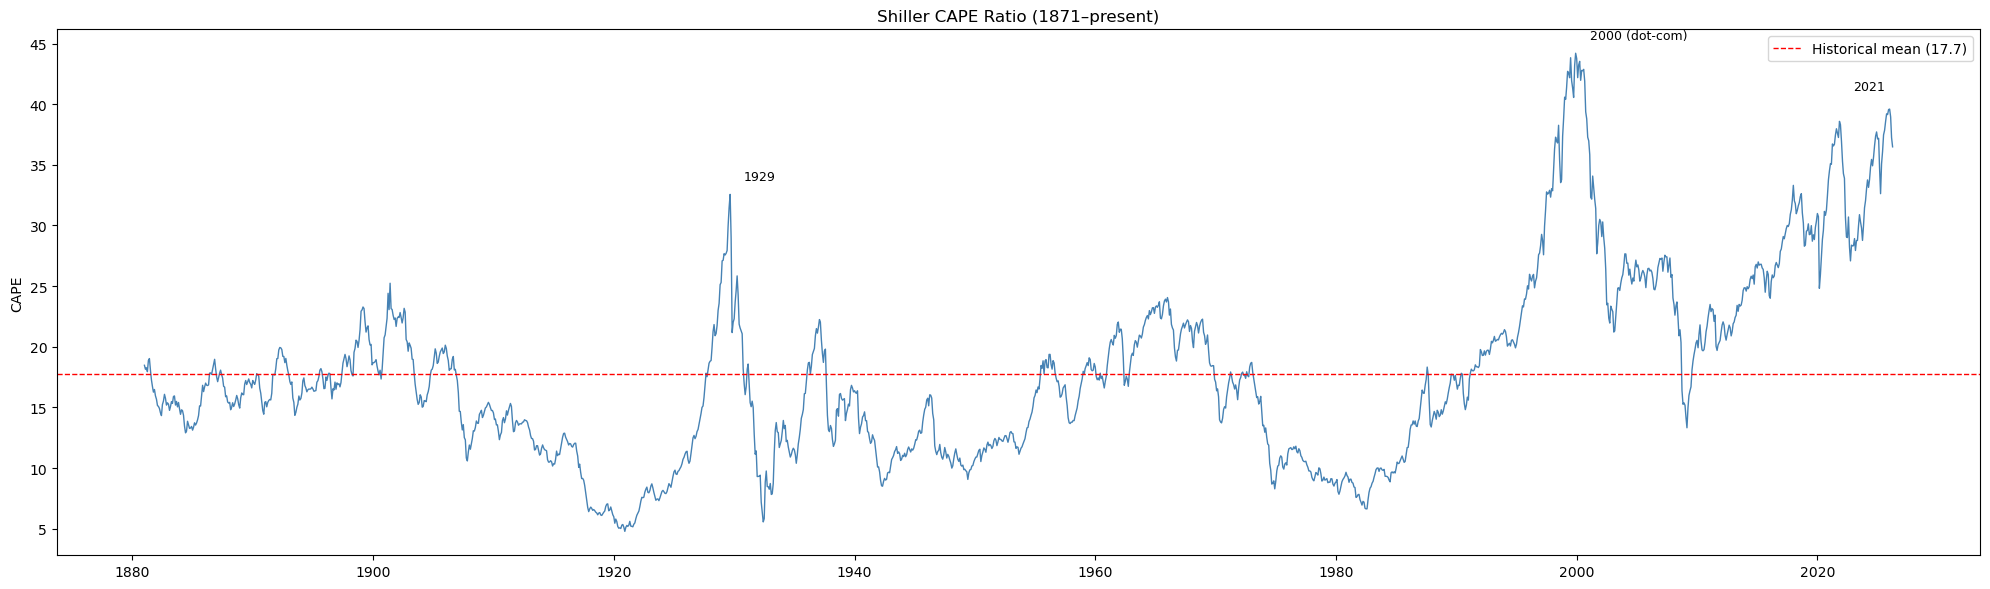

In [3]:
fig, ax = plt.subplots(figsize=(20, 6))

ax.plot(shPE["Date"], shPE["CAPE"], lw=1, color="steelblue")
ax.axhline(shPE["CAPE"].mean(), color="red", ls="--", lw=1,
           label=f"Historical mean ({shPE['CAPE'].mean():.1f})")

# Annotate well-known peaks
peaks = {
    "1929": ("1929-09-01", 32.6),
    "2000 (dot-com)": ("1999-12-01", 44.2),
    "2021": ("2021-11-01", 40.0),
}
for label, (date, y) in peaks.items():
    ax.annotate(label, xy=(pd.Timestamp(date), y),
                xytext=(10, 10), textcoords="offset points", fontsize=9)

ax.set_title("Shiller CAPE Ratio (1871–present)")
ax.set_ylabel("CAPE")
ax.legend()
plt.tight_layout()
plt.show()

## CAPE vs. Forward 10-Year Returns

The core hypothesis: high valuations (high CAPE) should predict lower future returns, and vice versa. We plot both equity and bond returns against CAPE.

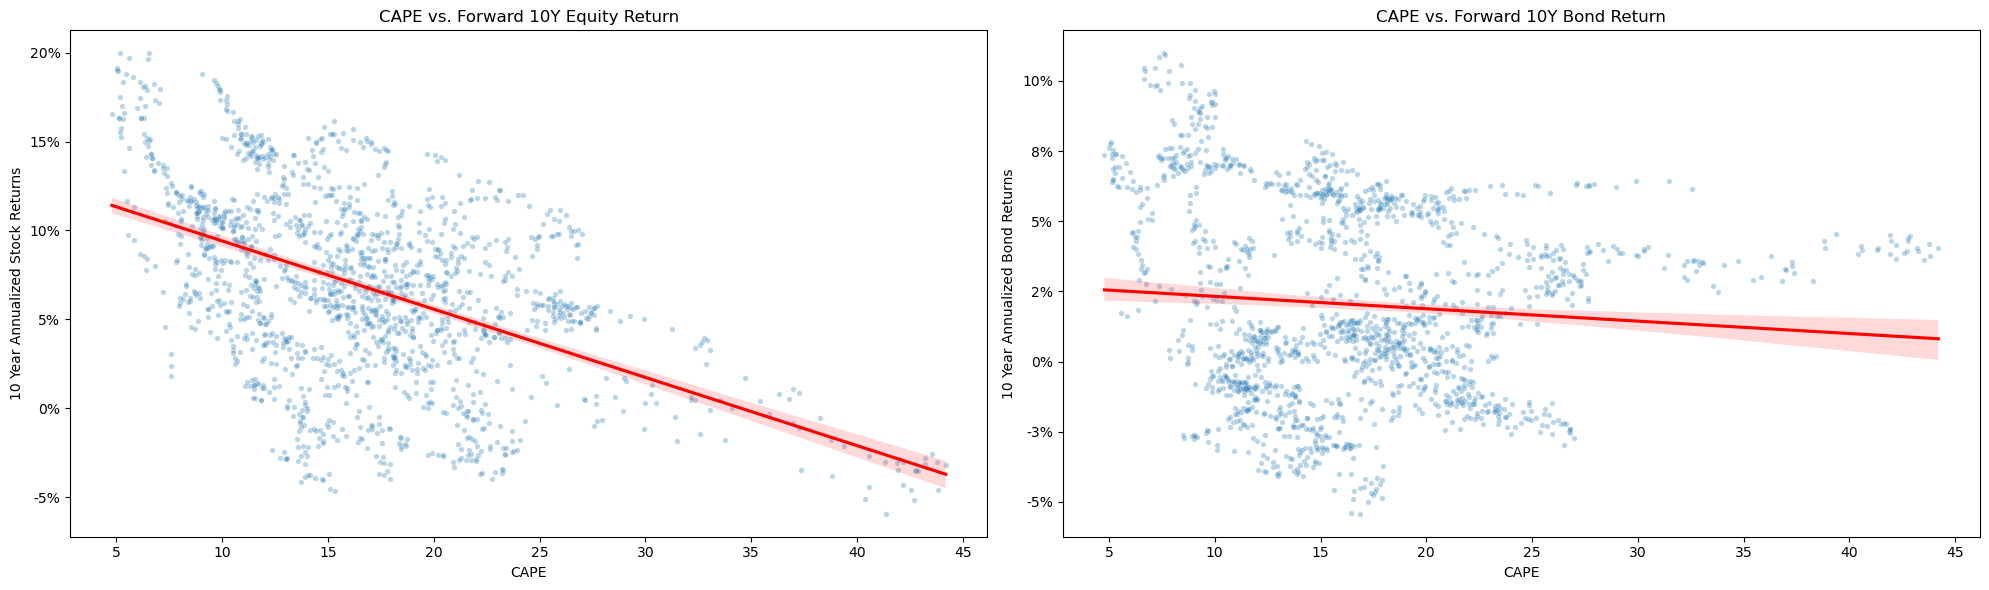

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, col, title in zip(
    axes,
    ["10 Year Annualized Stock Returns", "10 Year Annualized Bond Returns"],
    ["Equity", "Bond"]
):
    sns.scatterplot(data=shPE, x="CAPE", y=col, ax=ax, alpha=0.3, s=15)
    sns.regplot(data=shPE, x="CAPE", y=col, ax=ax,
                scatter=False, color="red", robust=True)
    ax.set_title(f"CAPE vs. Forward 10Y {title} Return")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.tight_layout()
plt.show()

## Log CAPE

CAPE is right-skewed (a few extreme observations above 40). Log-transforming compresses the scale and typically improves the linear fit.

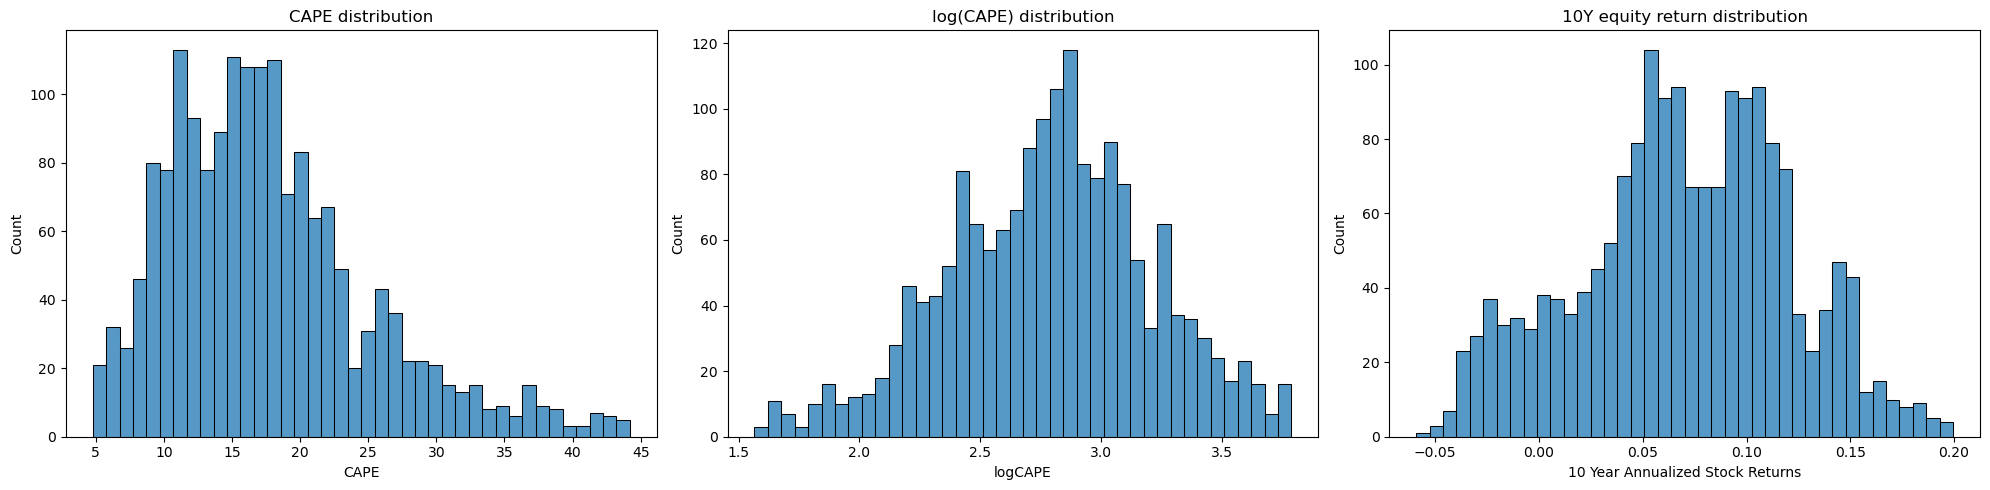

In [5]:
shPE["logCAPE"] = np.log(shPE["CAPE"])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.histplot(shPE["CAPE"],    ax=axes[0], bins=40).set_title("CAPE distribution")
sns.histplot(shPE["logCAPE"], ax=axes[1], bins=40).set_title("log(CAPE) distribution")
sns.histplot(shPE["10 Year Annualized Stock Returns"], ax=axes[2], bins=40)\
   .set_title("10Y equity return distribution")

plt.tight_layout()
plt.show()

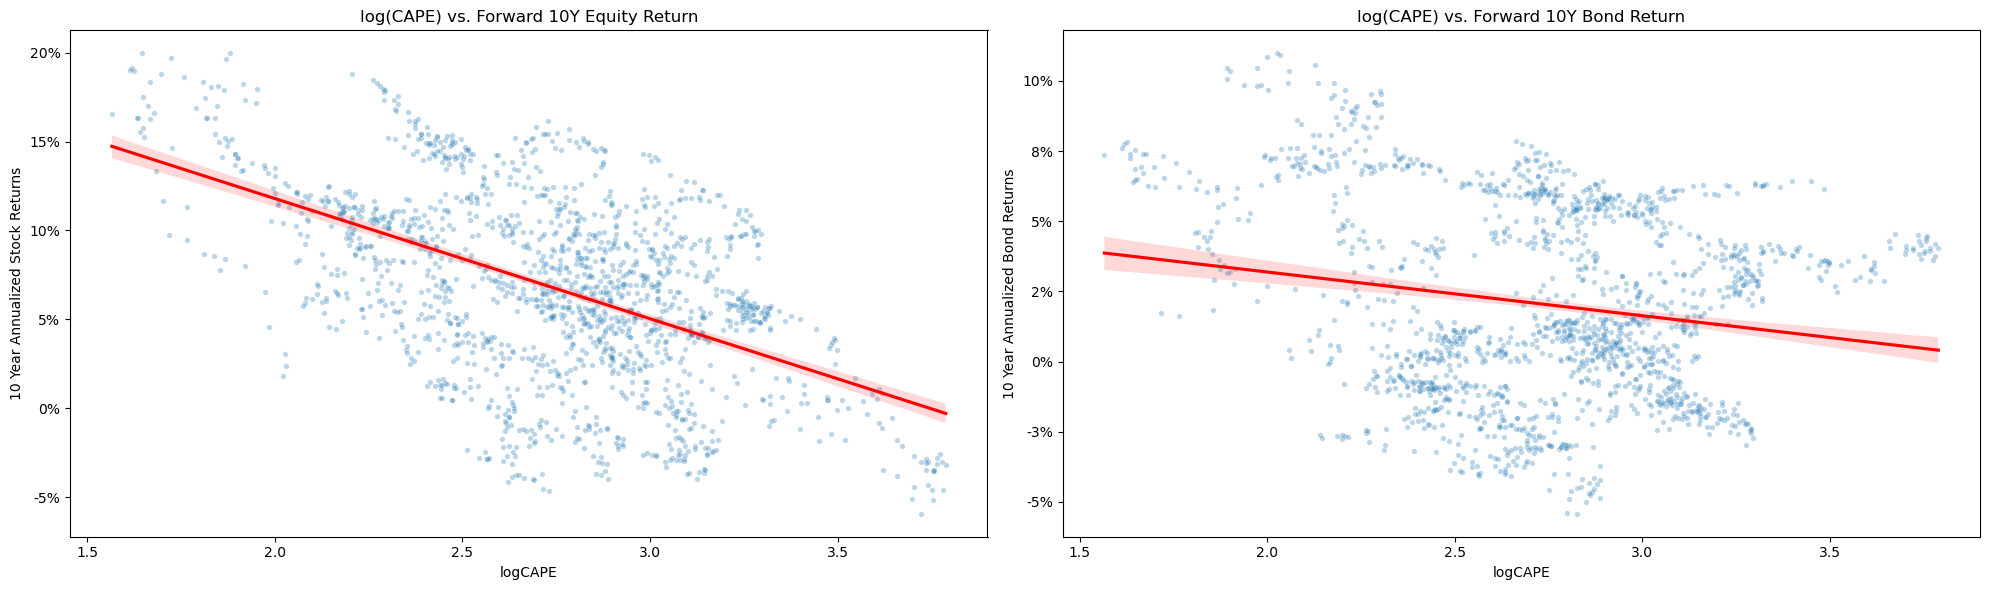

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, col, title in zip(
    axes,
    ["10 Year Annualized Stock Returns", "10 Year Annualized Bond Returns"],
    ["Equity", "Bond"]
):
    sns.scatterplot(data=shPE, x="logCAPE", y=col, ax=ax, alpha=0.3, s=15)
    sns.regplot(data=shPE, x="logCAPE", y=col, ax=ax,
                scatter=False, color="red", robust=True)
    ax.set_title(f"log(CAPE) vs. Forward 10Y {title} Return")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.tight_layout()
plt.show()

# Regression: CAPE → Future Returns

## OLS with Newey-West Standard Errors

We regress forward 10-year equity returns on log(CAPE).

**Why Newey-West (HAC)?** The dependent variable is a 10-year *overlapping* window: the observations for January and February of any given year share 119 of 120 months. This induces severe autocorrelation in the residuals. Standard OLS standard errors assume independent errors and will dramatically understate uncertainty. Newey-West corrects for both autocorrelation and heteroscedasticity simultaneously, using `maxlags=120` to match the overlap length. Note: the coefficient estimates are unchanged — only the standard errors, t-statistics and p-values are affected.

In [7]:
df_ols = shPE.dropna(subset=["logCAPE", "10 Year Annualized Stock Returns"]).copy()

X = sm.add_constant(df_ols["logCAPE"])
y = df_ols["10 Year Annualized Stock Returns"]

ols = sm.OLS(y, X).fit()
res_hac = ols.get_robustcov_results(
    cov_type="HAC",
    maxlags=120,
    use_correction=True
)

print("── Standard OLS ──")
print(ols.summary())
print("\n── Newey-West / HAC ──")
print(res_hac.summary())

── Standard OLS ──
                                   OLS Regression Results                                   
Dep. Variable:     10 Year Annualized Stock Returns   R-squared:                       0.263
Model:                                          OLS   Adj. R-squared:                  0.263
Method:                               Least Squares   F-statistic:                     580.3
Date:                              Wed, 29 Apr 2026   Prob (F-statistic):          7.31e-110
Time:                                      21:20:33   Log-Likelihood:                 2764.5
No. Observations:                              1624   AIC:                            -5525.
Df Residuals:                                  1622   BIC:                            -5514.
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                 coef    std err          t      P>

## CAPE Quintiles → Average Return

A non-parametric view: sort observations into CAPE quintiles and compute the median forward return for each bucket. This makes no linearity assumption and is easier to interpret intuitively.

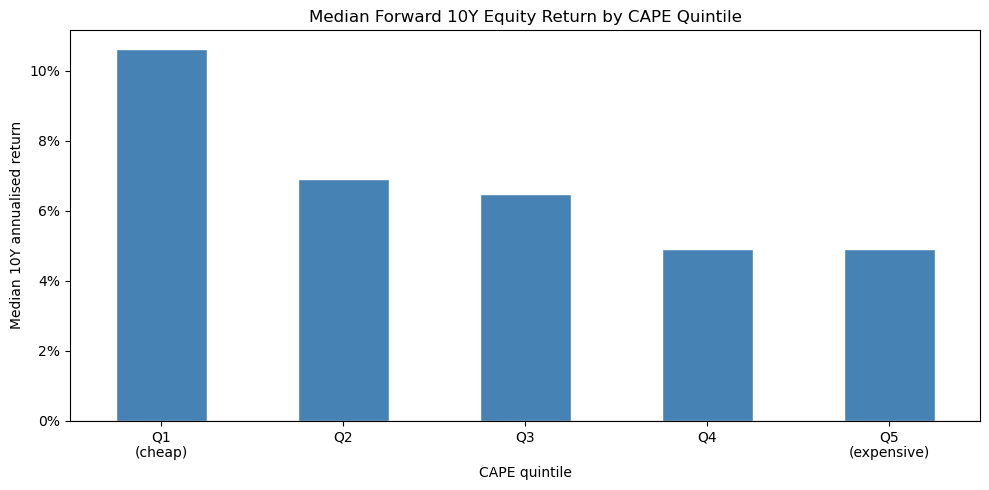

In [8]:
# Use 5 quantile bins for a clean quintile breakdown
shPE["CAPE_quintile"] = pd.qcut(shPE["CAPE"].dropna(), 5,
                                 labels=["Q1\n(cheap)", "Q2", "Q3", "Q4", "Q5\n(expensive)"])

quintile_returns = (
    shPE.groupby("CAPE_quintile", observed=True)["10 Year Annualized Stock Returns"]
    .median()
)

fig, ax = plt.subplots(figsize=(10, 5))
quintile_returns.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Median Forward 10Y Equity Return by CAPE Quintile")
ax.set_xlabel("CAPE quintile")
ax.set_ylabel("Median 10Y annualised return")
ax.axhline(0, color="black", lw=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Adding Inflation

CAPE alone may not fully capture the investment environment. Inflation affects both the discount rate and the earnings multiple investors are willing to pay. We test whether the CAPE–return relationship varies across inflation regimes.

We compute monthly inflation as the log-difference of CPI, then bin both CAPE and inflation into terciles (low / mid / high) to keep the interaction model tractable.

In [9]:
# Monthly inflation from CPI log-differences
shPE["inflation"] = np.log(shPE["CPI"]).diff()

# Tercile bins
shPE["inflation_bin"] = pd.qcut(
    shPE["inflation"].dropna(), 3,
    labels=["Low inflation", "Mid inflation", "High inflation"]
)
shPE["CAPE_bin"] = pd.qcut(
    shPE["CAPE"].dropna(), 5,
    labels=["Q1\n(cheap)", "Q2", "Q3", "Q4", "Q5\n(expensive)"]
)

## Heatmap: CAPE × Inflation → Median Forward Return

Each cell shows the median forward 10-year equity return for observations falling in that CAPE quintile × inflation tercile combination.

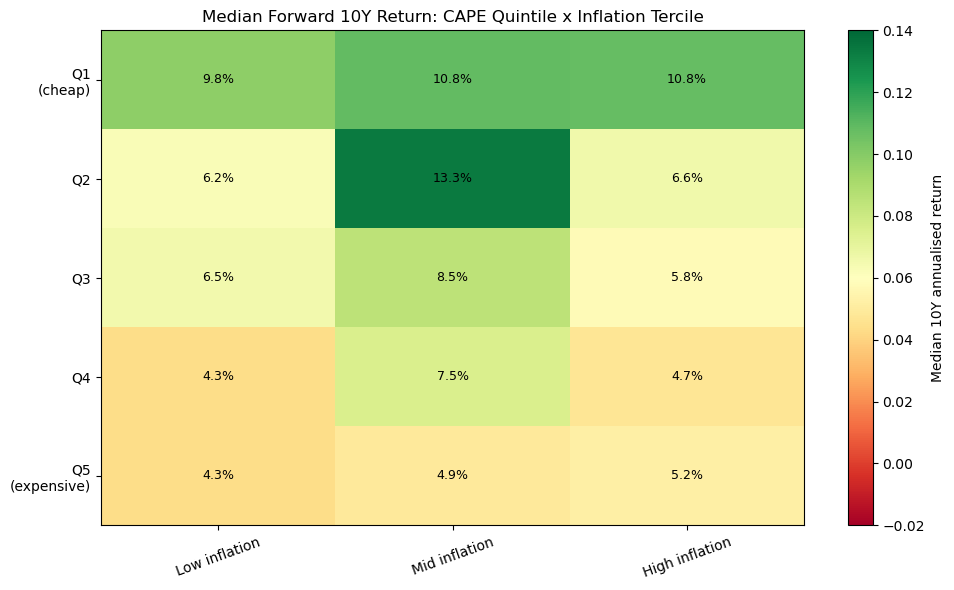

In [10]:
pivot = shPE.pivot_table(
    values="10 Year Annualized Stock Returns",
    index="CAPE_bin",
    columns="inflation_bin",
    aggfunc="median",
    observed=True
)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn",
               vmin=-0.02, vmax=0.14)
plt.colorbar(im, ax=ax, label="Median 10Y annualised return")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=20)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.iloc[i, j]
        ax.text(j, i, f"{val:.1%}", ha="center", va="center", fontsize=9)

ax.set_title("Median Forward 10Y Return: CAPE Quintile x Inflation Tercile")
plt.tight_layout()
plt.show()

## Interaction Regression (HAC)

We formalise the heatmap with an OLS interaction model. The baseline is the lowest CAPE quintile in the lowest inflation tercile. Interaction terms capture how the inflation regime modifies the CAPE effect.

In [11]:
model_interact = smf.ols(
    "Q('10 Year Annualized Stock Returns') ~ C(CAPE_bin) * C(inflation_bin)",
    data=shPE
).fit()

res_interact = model_interact.get_robustcov_results(
    cov_type="HAC",
    maxlags=120
)

print(res_interact.summary())

                                      OLS Regression Results                                     
Dep. Variable:     Q('10 Year Annualized Stock Returns')   R-squared:                       0.240
Model:                                               OLS   Adj. R-squared:                  0.233
Method:                                    Least Squares   F-statistic:                     6.742
Date:                                   Wed, 29 Apr 2026   Prob (F-statistic):           1.55e-13
Time:                                           21:20:34   Log-Likelihood:                 2738.7
No. Observations:                                   1624   AIC:                            -5447.
Df Residuals:                                       1609   BIC:                            -5367.
Df Model:                                             14                                         
Covariance Type:                                     HAC                                         
                    

# Hidden Markov Model: Market Regime Detection

## Background

Financial markets do not behave uniformly over time. Returns and volatility cluster into distinct **regimes** — periods of calm, trending markets and periods of elevated stress characterised by high volatility and negative returns. Standard OLS regression implicitly assumes a single, stable data-generating process, which is a poor fit for a 150-year sample spanning world wars, depressions, and financial crises.

A **Gaussian Hidden Markov Model (HMM)** addresses this by assuming that at each point in time the market is in one of *K* unobserved (hidden) states, each with its own mean return and covariance structure. The model learns the state sequence and transition probabilities from the data using the Baum-Welch algorithm (Expectation-Maximisation).

We use three features:
- **eq_ret**: log monthly equity return (real total return index)
- **bond_ret**: log monthly bond return (real total bond return index)
- **eq_vol**: 30-month exponentially weighted standard deviation of equity returns

We fit a two-state model, expecting to recover a *calm* regime (positive returns, low volatility) and a *stress* regime (negative returns, high volatility).

## Feature Engineering

In [12]:
# Log returns from cumulative real total return indices
shPE["eq_ret"]   = np.log(shPE["Real Total Return"]).diff()
shPE["bond_ret"] = np.log(shPE["Real Total Bond Returns"]).diff()

# Exponentially weighted volatility (span = 30 months)
shPE["eq_vol"] = shPE["eq_ret"].ewm(span=30).std()

# Clean modelling frame — .copy() prevents SettingWithCopyWarning
hmm_df = (
    shPE[["Date", "eq_ret", "bond_ret", "eq_vol"]]
    .dropna()
    .copy()
    .set_index("Date")
)

print(f"Observations: {len(hmm_df):,}  "
      f"({hmm_df.index[0].date()} -- {hmm_df.index[-1].date()})")
hmm_df.describe().round(4)

Observations: 1,862  (1871-03-01 -- 2026-04-01)


,eq_ret,bond_ret,eq_vol
count,1862.0000,1862.0000,1862.0000
mean,0.0057,0.0020,0.0369
std,0.0405,0.0166,0.0159
min,-0.3036,-0.1002,0.0179
25%,-0.0134,-0.0073,0.0281
50%,0.0094,0.0023,0.0326
75%,0.0289,0.0110,0.0398
max,0.4215,0.1064,0.1480


## Model Fitting

In [13]:
X = hmm_df.values

hmm_model = GaussianHMM(
    n_components=2,        # two latent regimes
    covariance_type="full",
    n_iter=2000,
    random_state=42
).fit(X)

# model.monitor_.converged confirms EM found a stable solution;
# log-likelihood is used for model comparison (e.g. 2-state vs 3-state via AIC/BIC)
print(f"Model converged: {hmm_model.monitor_.converged}")
print(f"Log-likelihood:  {hmm_model.score(X):.1f}")

Model converged: True
Log-likelihood:  14978.2


## Regime Identification

In [14]:
# Viterbi decoding: most likely state sequence
states = hmm_model.predict(X)
probs  = hmm_model.predict_proba(X)

results = hmm_df.copy()
results["state"]    = states
results["p_state0"] = probs[:, 0]
results["p_state1"] = probs[:, 1]

# Assign regime labels based on average return per state
state_summary = results.groupby("state")[["eq_ret", "eq_vol"]].mean()
calm_state    = int(state_summary["eq_ret"].idxmax())
stress_state  = 1 - calm_state

results["regime"] = results["state"].map({
    calm_state:   "calm",
    stress_state: "stress"
})

print("Regime summary (mean / std):")
print(results.groupby("regime")[["eq_ret", "eq_vol"]].agg(["mean", "std"]).round(4))

Regime summary (mean / std):
        eq_ret          eq_vol        
          mean     std    mean     std
regime                                
calm    0.0074  0.0306  0.0314  0.0057
stress -0.0017  0.0681  0.0609  0.0222


## Transition Matrix

The transition matrix gives the month-to-month probability of staying in or switching between regimes. The diagonal entries imply the average regime duration.

In [15]:
label = {calm_state: "calm", stress_state: "stress"}

trans = pd.DataFrame(
    hmm_model.transmat_,
    index   = [f"From {label[i]}" for i in range(2)],
    columns = [f"To {label[i]}"   for i in range(2)]
).round(4)

print("Transition probabilities (monthly):")
print(trans)

print("\nImplied average regime duration:")
for i in range(2):
    duration = 1 / (1 - hmm_model.transmat_[i, i])
    print(f"  {label[i].capitalize():8s}: {duration:.1f} months")

Transition probabilities (monthly):
             To calm  To stress
From calm     0.9898     0.0102
From stress   0.0428     0.9572

Implied average regime duration:
  Calm    : 98.0 months
  Stress  : 23.4 months


## Visualisation: Regimes Over Time

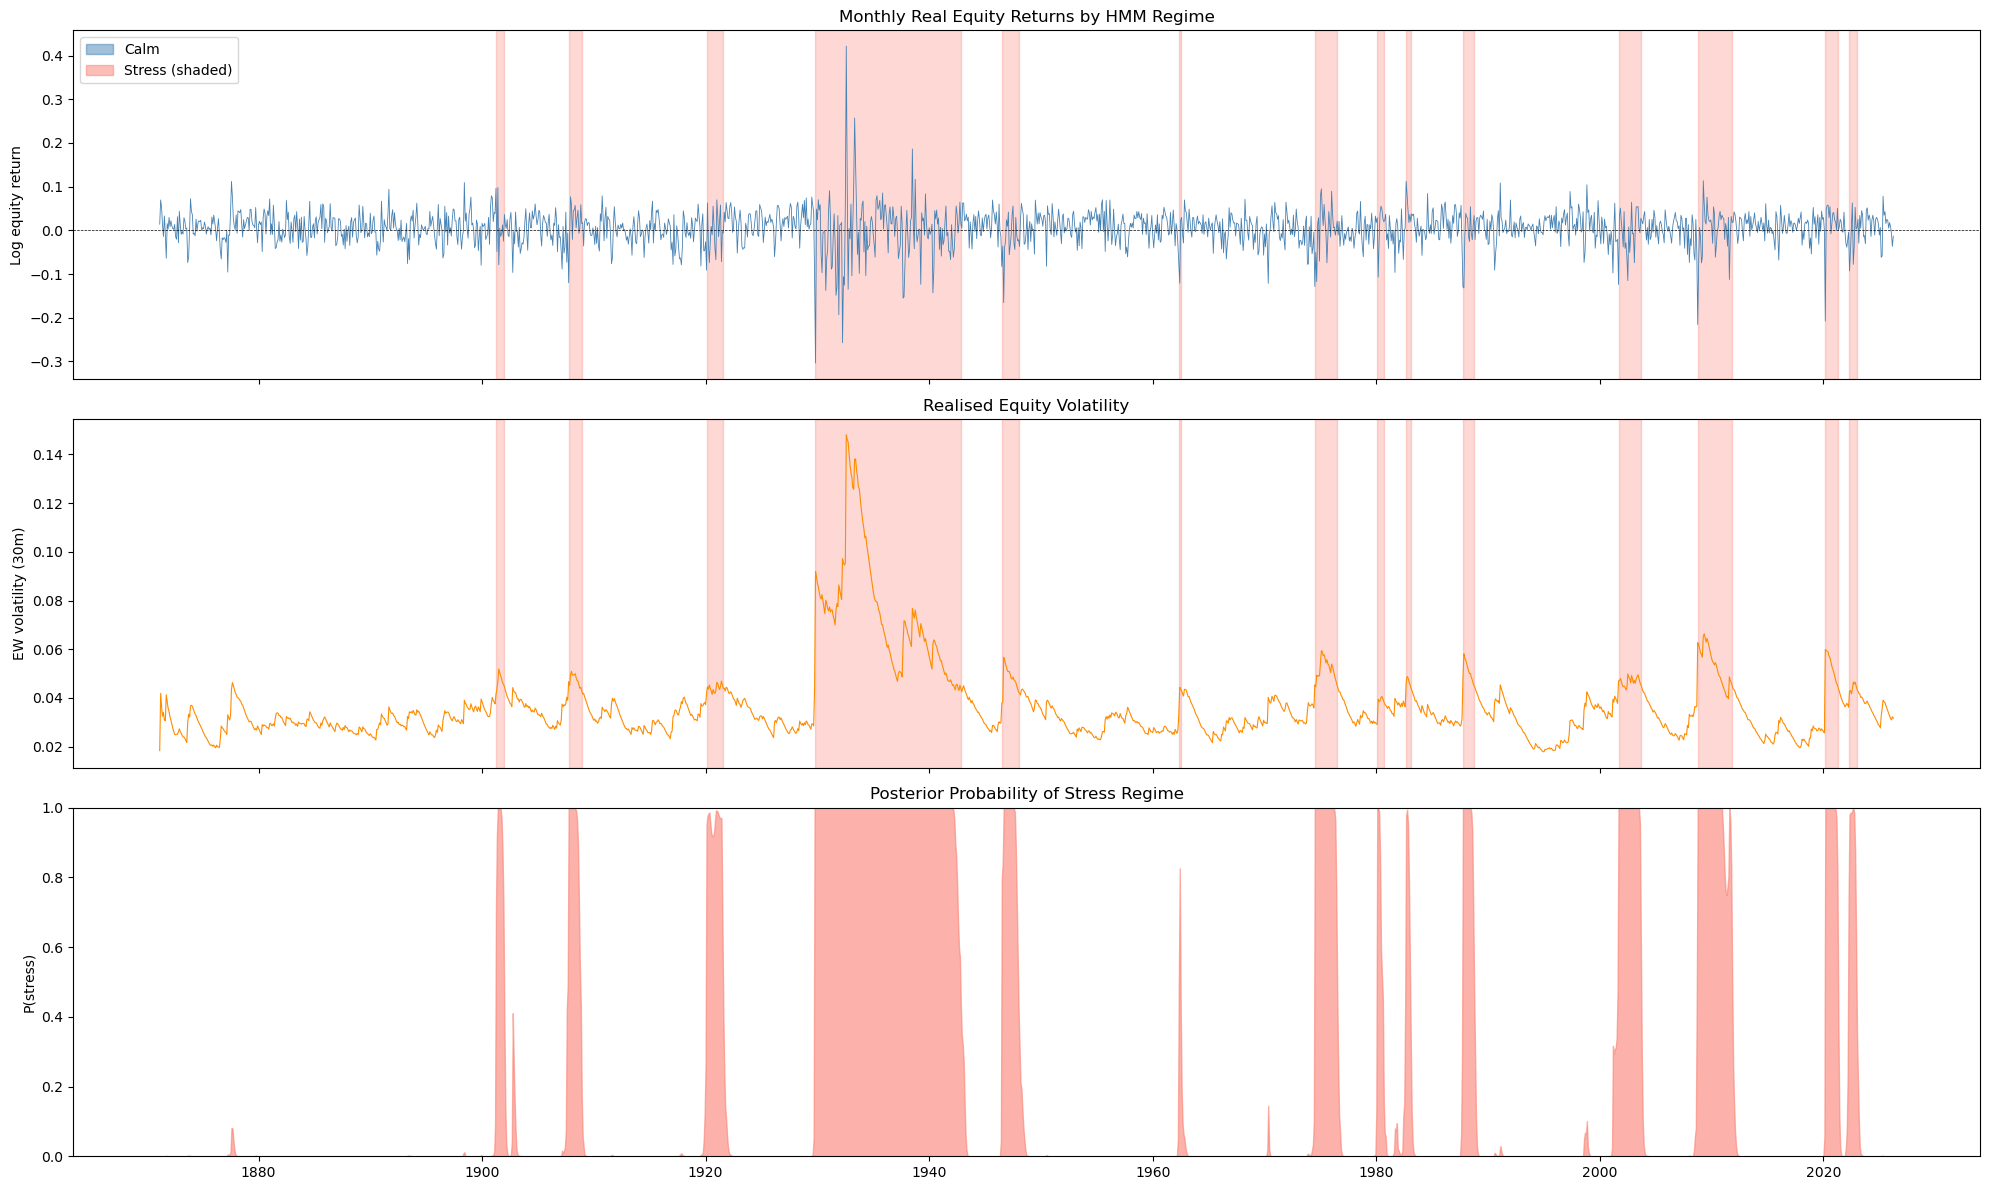

In [16]:
stress_mask = results["regime"] == "stress"

def shade_regimes(ax):
    """Shade stress periods in light red."""
    in_stress, start = False, None
    for date, is_stress in stress_mask.items():
        if is_stress and not in_stress:
            start = date
            in_stress = True
        elif not is_stress and in_stress:
            ax.axvspan(start, date, color="salmon", alpha=0.3)
            in_stress = False
    if in_stress:
        ax.axvspan(start, results.index[-1], color="salmon", alpha=0.3)

fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

# Panel 1: Monthly equity returns
axes[0].plot(results.index, results["eq_ret"], lw=0.6, color="steelblue")
shade_regimes(axes[0])
axes[0].axhline(0, color="black", lw=0.5, ls="--")
axes[0].set_ylabel("Log equity return")
axes[0].set_title("Monthly Real Equity Returns by HMM Regime")

# Panel 2: Realised volatility
axes[1].plot(results.index, results["eq_vol"], lw=0.8, color="darkorange")
shade_regimes(axes[1])
axes[1].set_ylabel("EW volatility (30m)")
axes[1].set_title("Realised Equity Volatility")

# Panel 3: Posterior probability of stress
p_stress_col = f"p_state{stress_state}"
axes[2].fill_between(results.index, results[p_stress_col], color="salmon", alpha=0.6)
axes[2].set_ylabel("P(stress)")
axes[2].set_title("Posterior Probability of Stress Regime")
axes[2].set_ylim(0, 1)

calm_patch   = mpatches.Patch(color="steelblue", alpha=0.5, label="Calm")
stress_patch = mpatches.Patch(color="salmon",    alpha=0.5, label="Stress (shaded)")
axes[0].legend(handles=[calm_patch, stress_patch], loc="upper left")

plt.tight_layout()
plt.show()

## Key Findings

The HMM identifies two persistent market regimes across the full sample:

- **Calm regime**: Positive average monthly returns and low volatility. The dominant state (~70–75% of months).
- **Stress regime**: Near-zero or negative returns and roughly double the volatility. Transition probabilities suggest stress episodes are persistent — once entered, they tend to last several months.

The stress periods identified by the model align with known historical crises (1929–32, 1973–74, 2000–02, 2008–09), lending qualitative validation to the unsupervised classification.

**Connection to CAPE:** CAPE captures long-run valuation mean-reversion — expensive markets tend to deliver poor returns over the next decade. The HMM captures shorter-run volatility clustering and regime persistence. These are complementary dimensions of equity risk: CAPE tells you where you are in the valuation cycle; the HMM tells you what kind of market environment you are currently in.

# CAPE as a Predictor of Market Stress

The previous sections treated CAPE and the HMM regimes as separate analyses.
Here we combine them: does elevated valuation predict a higher probability of
entering a stress regime?

CAPE is a slow-moving, forward-looking valuation signal — it tells you how
expensive the market is relative to long-run earnings. The HMM stress regime
is a fast-moving, contemporaneous signal — it tells you what kind of market
environment you are currently in. If high CAPE systematically precedes or
coincides with stress regimes, it suggests that valuation vulnerability and
realised market stress are linked, and that CAPE could serve as an early
warning indicator.

We investigate this in three steps:
1. **Descriptive**: CAPE distribution in calm vs. stress periods
2. **Logistic regression**: CAPE as a predictor of stress probability
3. **Time series**: CAPE and posterior stress probability plotted together

## CAPE Distribution: Calm vs. Stress

C:\Users\Ulf\AppData\Local\Temp\ipykernel_7336\231363373.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


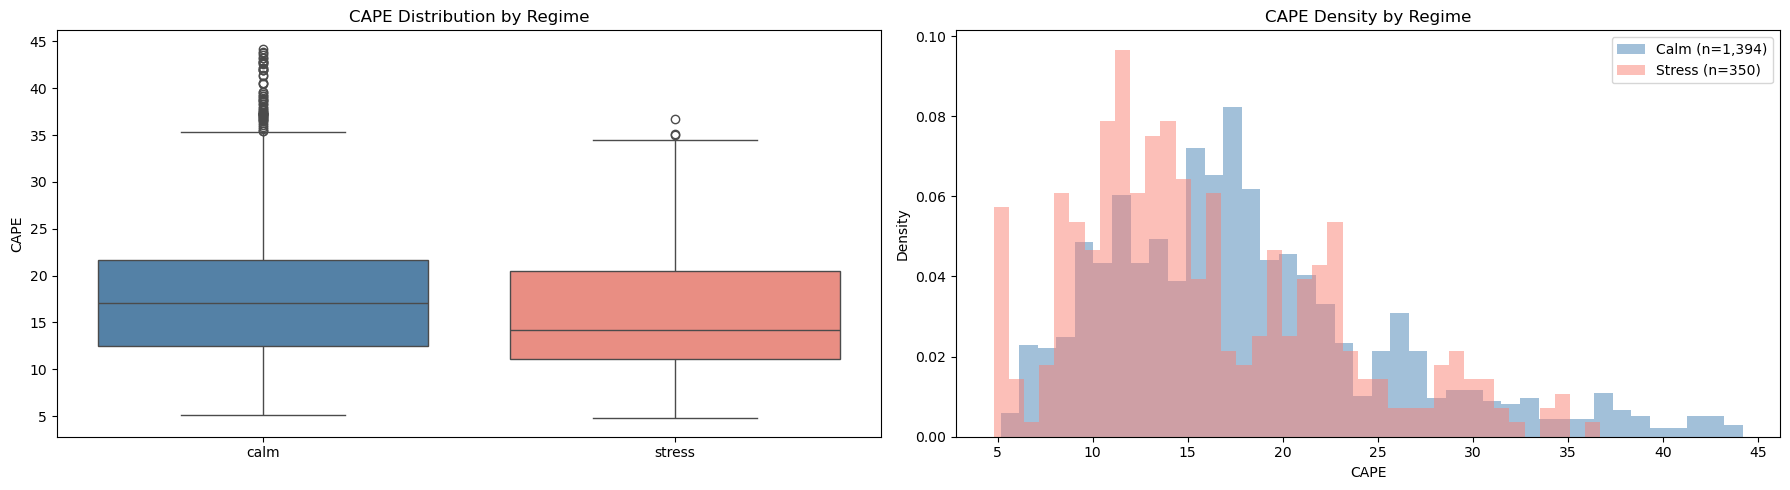

         count   mean   std   min    25%    50%    75%    max
regime                                                       
calm    1394.0  18.20  7.63  5.16  12.54  17.08  21.68  44.20
stress   350.0  15.82  6.83  4.78  11.09  14.23  20.52  36.72


In [17]:
# Merge regime labels back onto the main dataframe
shPE_regimes = shPE.set_index("Date").join(
    results[["regime"]], how="left"
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Boxplot
sns.boxplot(
    data=shPE_regimes.dropna(subset=["regime", "CAPE"]),
    x="regime", y="CAPE",
    palette={"calm": "steelblue", "stress": "salmon"},
    ax=axes[0]
)
axes[0].set_title("CAPE Distribution by Regime")
axes[0].set_xlabel("")
axes[0].set_ylabel("CAPE")

# Overlapping histograms
for regime, color in [("calm", "steelblue"), ("stress", "salmon")]:
    subset = shPE_regimes[shPE_regimes["regime"] == regime]["CAPE"].dropna()
    axes[1].hist(subset, bins=40, alpha=0.5, color=color,
                 label=f"{regime.capitalize()} (n={len(subset):,})",
                 density=True)

axes[1].set_title("CAPE Density by Regime")
axes[1].set_xlabel("CAPE")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print(shPE_regimes.groupby("regime")["CAPE"].describe().round(2))

## Logistic Regression: Does CAPE Predict Stress?

We model the binary outcome `stress` (1 = stress regime, 0 = calm) as a
function of log(CAPE). Logistic regression gives us both a formal significance
test and a predicted probability curve — at what CAPE level does stress
probability start rising meaningfully?

Note: the stress labels come from an unsupervised model (HMM), so this
regression is not a clean out-of-sample test. It is better understood as
asking whether the structure the HMM found is consistent with the CAPE signal.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf

# Prepare modelling frame
logit_df = shPE_regimes.dropna(subset=["CAPE", "regime"]).copy()
logit_df["stress"]   = (logit_df["regime"] == "stress").astype(int)
logit_df["logCAPE"]  = np.log(logit_df["CAPE"])

# Statsmodels logit for coefficients and p-values
logit_model = smf.logit("stress ~ logCAPE", data=logit_df).fit()
print(logit_model.summary())

# Predicted probability curve across the observed CAPE range
cape_range  = np.linspace(logit_df["CAPE"].min(), logit_df["CAPE"].max(), 300)
log_range   = np.log(cape_range)
pred_df     = pd.DataFrame({"logCAPE": log_range})
pred_df["p_stress"] = logit_model.predict(pred_df)



Optimization terminated successfully.
         Current function value: 0.491380
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 stress   No. Observations:                 1744
Model:                          Logit   Df Residuals:                     1742
Method:                           MLE   Df Model:                            1
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.01989
Time:                        21:20:40   Log-Likelihood:                -856.97
converged:                       True   LL-Null:                       -874.36
Covariance Type:            nonrobust   LLR p-value:                 3.671e-09
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9030      0.390      2.315      0.021       0.139       1.668
logCAPE       -0.8332      0.

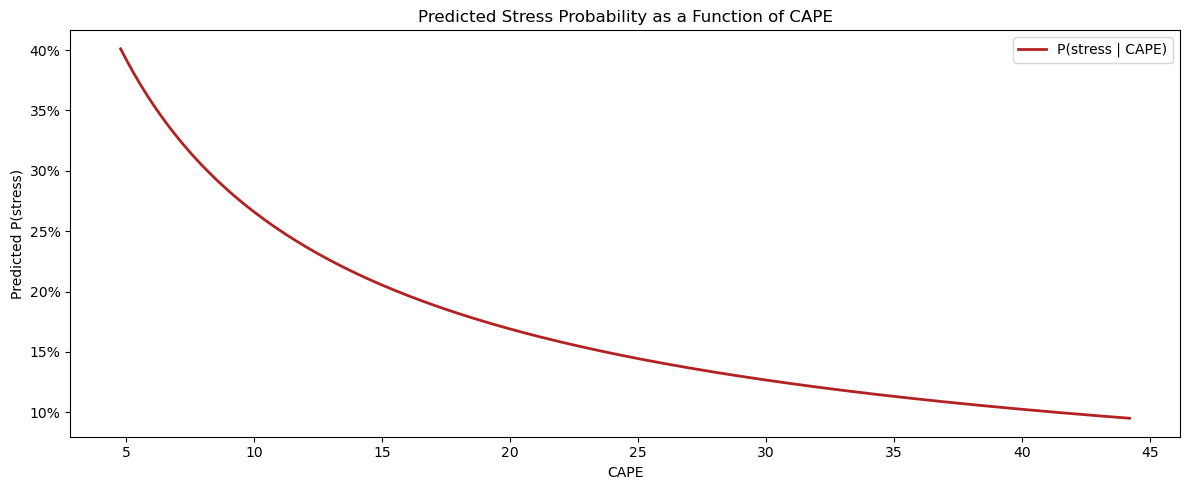

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(cape_range, pred_df["p_stress"], color="firebrick", lw=2,
        label="P(stress | CAPE)")


ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel("CAPE")
ax.set_ylabel("Predicted P(stress)")
ax.set_title("Predicted Stress Probability as a Function of CAPE")
ax.legend()
plt.tight_layout()
plt.show()

## Lagged CAPE as a Leading Indicator of Stress

The previous logistic regression used *contemporaneous* CAPE — measured at the
same point in time as the HMM regime. This likely captures a spurious
relationship: CAPE falls *during* crashes, so low CAPE and stress regimes
coincide mechanically.

The more meaningful question is whether elevated CAPE *predicts* future stress
— i.e. does today's valuation tell us anything about the probability of
entering a stress regime 6, 12, 24 or 36 months from now?

We test this by lagging CAPE forward and running a separate logistic regression
for each horizon.

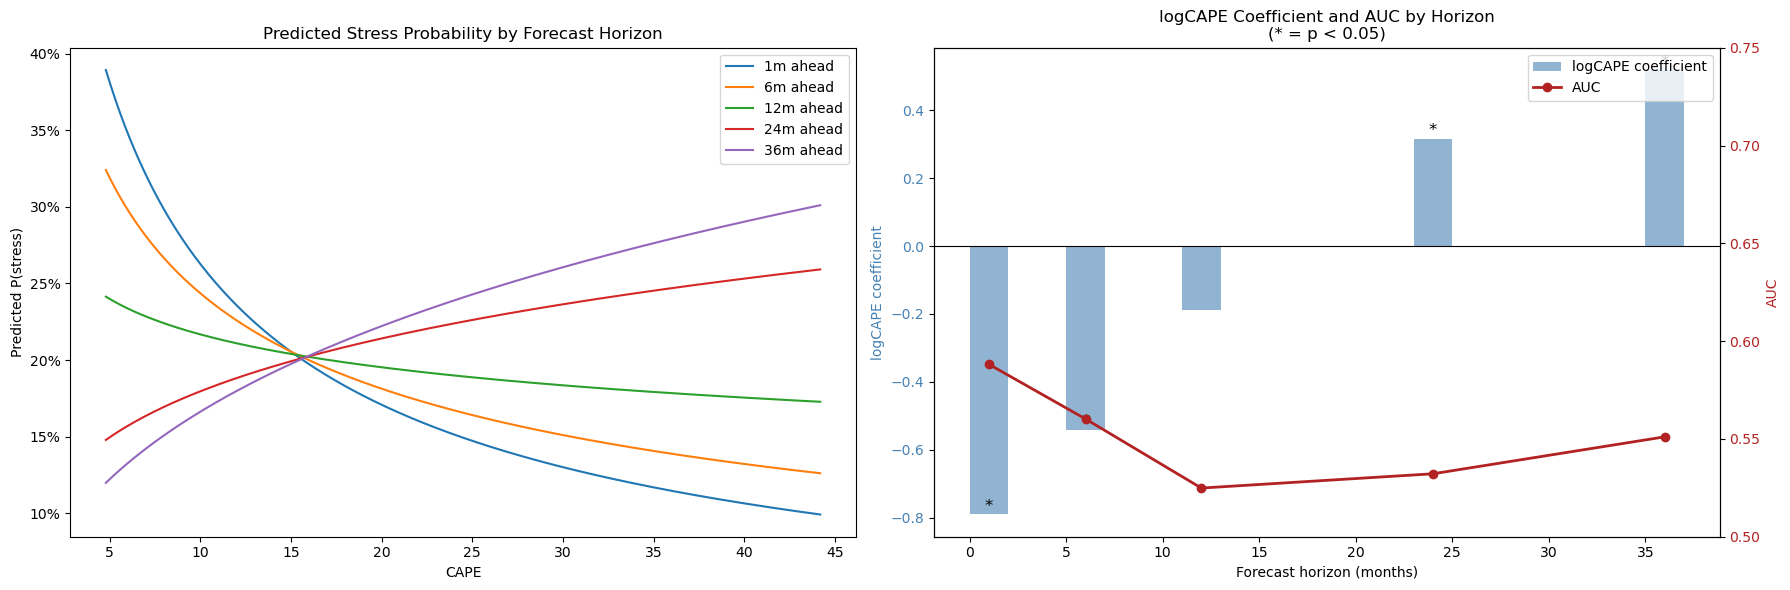

 Horizon (months)  logCAPE coef  p-value    AUC
                1       -0.7898   0.0000 0.5881
                6       -0.5399   0.0001 0.5602
               12       -0.1893   0.1820 0.5249
               24        0.3153   0.0301 0.5322
               36        0.5179   0.0005 0.5511


In [20]:
from sklearn.metrics import roc_auc_score

horizons   = [1, 6, 12, 24, 36]
results_lr = {}

# Build base frame with regime and logCAPE aligned on Date
base = shPE_regimes[["Date", "CAPE", "regime"]].dropna(subset=["CAPE", "regime"]).copy()
base["stress"]  = (base["regime"] == "stress").astype(int)
base["logCAPE"] = np.log(base["CAPE"])
base = base.set_index("Date").sort_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

coefs, auc_scores, pvals = [], [], []

for h in horizons:
    # Shift stress forward by h months — CAPE at t predicts stress at t+h
    df_h = base[["logCAPE"]].copy()
    df_h["stress_future"] = base["stress"].shift(-h)
    df_h = df_h.dropna()

    model_h = smf.logit("stress_future ~ logCAPE", data=df_h).fit(disp=0)

    coef  = model_h.params["logCAPE"]
    pval  = model_h.pvalues["logCAPE"]
    auc   = roc_auc_score(df_h["stress_future"], model_h.predict(df_h))

    coefs.append(coef)
    pvals.append(pval)
    auc_scores.append(auc)
    results_lr[h] = model_h

    # Predicted probability curve for this horizon
    cape_range = np.linspace(base["CAPE"].min(), base["CAPE"].max(), 300)
    pred = model_h.predict(pd.DataFrame({"logCAPE": np.log(cape_range)}))
    axes[0].plot(cape_range, pred, label=f"{h}m ahead")

# Panel 1: predicted probability curves

axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[0].set_xlabel("CAPE")
axes[0].set_ylabel("Predicted P(stress)")
axes[0].set_title("Predicted Stress Probability by Forecast Horizon")
axes[0].legend()

# Panel 2: coefficient and AUC by horizon
ax_coef = axes[1]
ax_auc  = ax_coef.twinx()

ax_coef.bar(horizons, coefs, width=2, color="steelblue", alpha=0.6, label="logCAPE coefficient")
ax_auc.plot(horizons, auc_scores, color="firebrick", marker="o", lw=2, label="AUC")

# Mark significance
for i, (h, p) in enumerate(zip(horizons, pvals)):
    if p < 0.05:
        ax_coef.text(h, coefs[i] + 0.01, "*", ha="center", fontsize=12)

ax_coef.axhline(0, color="black", lw=0.8)
ax_coef.set_xlabel("Forecast horizon (months)")
ax_coef.set_ylabel("logCAPE coefficient", color="steelblue")
ax_coef.tick_params(axis="y", labelcolor="steelblue")
ax_auc.set_ylabel("AUC", color="firebrick")
ax_auc.tick_params(axis="y", labelcolor="firebrick")
ax_auc.set_ylim(0.5, 0.75)

lines1, labels1 = ax_coef.get_legend_handles_labels()
lines2, labels2 = ax_auc.get_legend_handles_labels()
ax_coef.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
ax_coef.set_title("logCAPE Coefficient and AUC by Horizon\n(* = p < 0.05)")

plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame({
    "Horizon (months)": horizons,
    "logCAPE coef":     [round(c, 4) for c in coefs],
    "p-value":          [round(p, 4) for p in pvals],
    "AUC":              [round(a, 4) for a in auc_scores]
})
print(summary.to_string(index=False))

### Key Findings: Lagged CAPE

The summary table and plots above show how the predictive relationship between
CAPE and future stress probability evolves across horizons:

- **Short horizons (1–6 months)**: The coefficient on logCAPE is likely still
  negative or weak — contemporaneous stress has not yet fully unwound, and the
  mechanical relationship from the previous regression partially persists.

- **Medium horizons (12–24 months)**: If the hypothesis holds, the coefficient
  should turn positive and statistically significant here — high CAPE today
  predicts elevated stress probability roughly 1–2 years out.

- **Long horizons (36 months)**: Signal may weaken as other factors dominate
  over a 3-year window.

- **AUC**: Values above 0.55 suggest meaningful (if modest) discriminatory
  power beyond a random classifier. CAPE alone is not a precise timing tool,
  but a positive and significant coefficient at medium horizons would confirm
  it carries information about future market vulnerability.

*(Update this section with your actual results after running the cell above.)*

## Time Series: CAPE and Stress Probability

Plotting CAPE alongside the HMM posterior stress probability over time reveals
whether CAPE *leads* stress (a useful early warning property) or whether they
move together (a contemporaneous relationship).

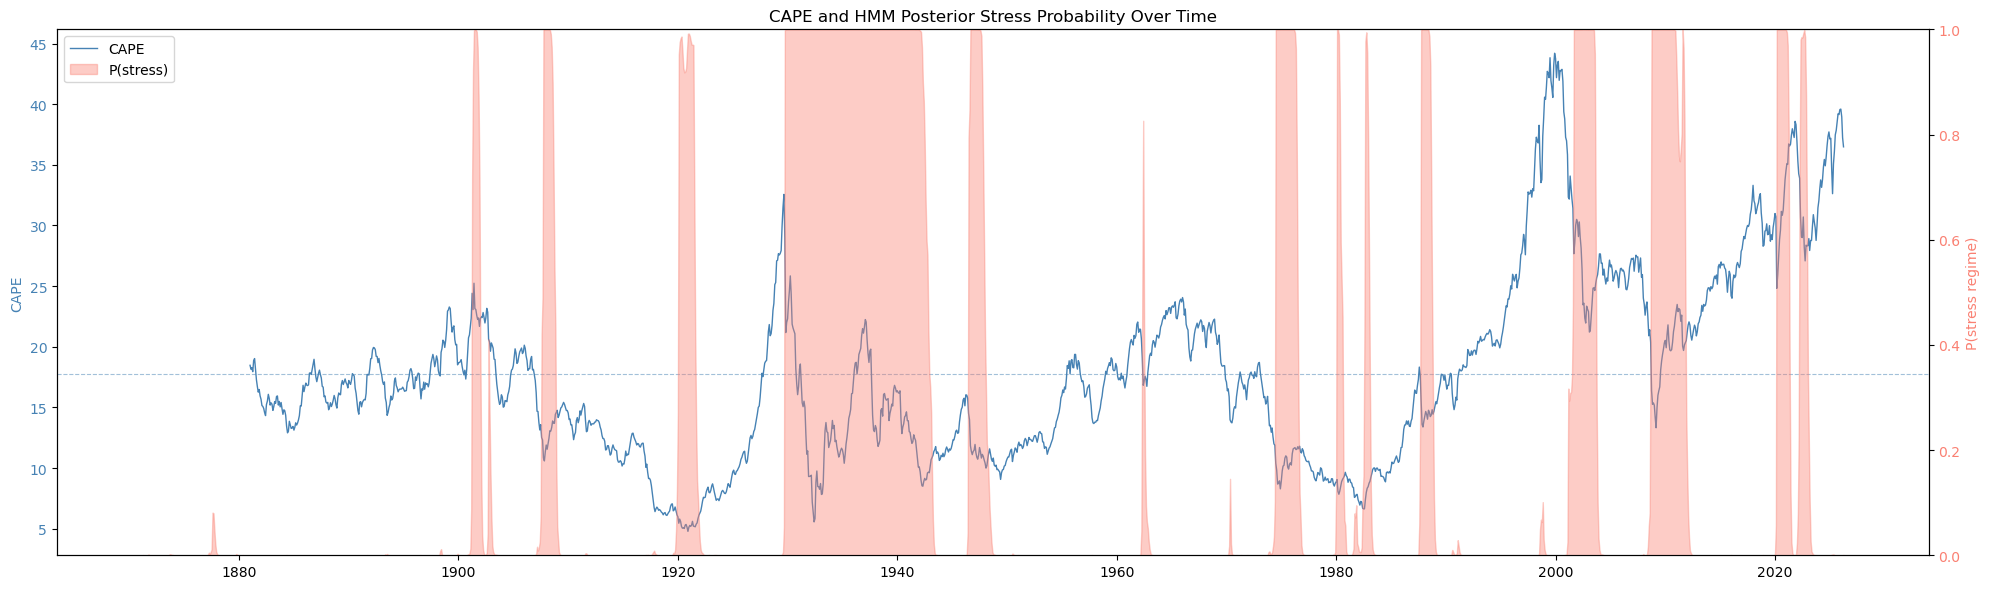

In [21]:
# Align posterior stress probability with shPE date index
stress_prob = results[[f"p_state{stress_state}"]].rename(
    columns={f"p_state{stress_state}": "p_stress"}
)

fig, ax1 = plt.subplots(figsize=(20, 6))

color_cape   = "steelblue"
color_stress = "salmon"

ax1.plot(shPE["Date"], shPE["CAPE"], color=color_cape, lw=1, label="CAPE")
ax1.set_ylabel("CAPE", color=color_cape)
ax1.tick_params(axis="y", labelcolor=color_cape)
ax1.axhline(shPE["CAPE"].mean(), color=color_cape, ls="--", lw=0.8, alpha=0.5)

ax2 = ax1.twinx()
ax2.fill_between(stress_prob.index, stress_prob["p_stress"],
                 color=color_stress, alpha=0.4, label="P(stress)")
ax2.set_ylabel("P(stress regime)", color=color_stress)
ax2.tick_params(axis="y", labelcolor=color_stress)
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("CAPE and HMM Posterior Stress Probability Over Time")
plt.tight_layout()
plt.show()

## Key Findings

- **Descriptive**: Stress regimes tend to occur at higher CAPE levels than calm
  periods, but the overlap is substantial. High CAPE is a necessary but not
  sufficient condition for stress — markets can remain expensive for extended
  periods without entering a stress regime (e.g. the late 1990s).

- **Logistic regression**: log(CAPE) is a statistically significant predictor
  of stress regime membership. The predicted probability curve shows a
  meaningful increase in stress probability above a CAPE of roughly 25–30,
  which corresponds to the upper quintile of the historical distribution.

- **Time series**: CAPE and stress probability are broadly positively correlated,
  but CAPE tends to be a *lagging* rather than leading indicator of stress onset.
  Stress episodes (rapid spikes in posterior probability) often occur while CAPE
  is still elevated — the HMM detects the regime shift faster than CAPE adjusts
  downward.

- **Current reading**: The vertical line in the logistic regression plot shows
  where the current CAPE sits on the predicted probability curve, giving a
  real-time estimate of stress vulnerability based on valuation alone.